## Описание таблиц

### 1. **sales**
Таблицы с продажами пива, сигарет и анальгетиков.

| Переменная | Описание |
|------------|----------|
| **upc**    | Номер UPC |
| **store**  | Номер магазина |
| **week**   | Номер недели |
| **move**   | Количество проданных единиц |
| **price**  | Розничная цена |
| **qty**    | Количество товаров в упаковке |
| **sale**   | Код акции: 'B' — бонусная покупка, 'C' — купон, 'S' — простая скидка |

### 2. **upc**
Таблицы с описанием товаров (пиво, сигареты, анальгетики).

| Переменная | Описание |
|------------|----------|
| **com_code** | Не важна |
| **upc**      | Номер UPC |
| **descrip**  | Название товара |
| **size**     | Размер товара |
| **case**     | Не важна |
| **nitem**    | Количество товаров в упаковке |

### 3. **demographic**
Данные о демографии и магазинах.

| Переменная  | Описание |
|-------------|----------|
| **store**   | Номер магазина |
| **age60**   | % населения старше 60 лет |
| **age9**    | % населения младше 9 лет |
| **educ**    | % выпускников колледжей |
| **ethnic**  | % чернокожих и латиноамериканцев |
| **income**  | Логарифм медианного дохода |
| **hhlarge** | % домохозяйств с 5 и более членами |
| **workwom** | % работающих женщин на полный рабочий день |
| **hval150** | % домохозяйств с доходом выше $150,000 |
| **sstrdist**| Расстояние до ближайшего магазина в сети |
| **sstrvol** | Соотношение продаж данного магазина к ближайшему магазину в сети |
| **cpdist5** | Среднее расстояние до ближайших 5 супермаркетов |
| **cpwvol5** | Соотношение продаж данного магазина к среднему значению 5 ближайших магазинов |


In [1]:
#!pip install pyarrow
#!pip install fastparquet

In [2]:
import pandas as pd

DATA_PATH = r'C:\Users\Omen\Desktop\DS_Intern_test\data'  

# Продажи
beer_sales = pd.read_parquet(f'{DATA_PATH}/beer_sales_data.parquet')
cig_sales = pd.read_parquet(f'{DATA_PATH}/cig_sales_data.parquet')
ana_sales = pd.read_parquet(f'{DATA_PATH}/ana_sales_data.parquet')

# Данные о демографии и магазинах
demographic_data = pd.read_parquet(f'{DATA_PATH}/demographic_data.parquet')

# Данные о товарах
beer_upc = pd.read_parquet(f'{DATA_PATH}/beer_upc.parquet')
cig_upc = pd.read_parquet(f'{DATA_PATH}/cig_upc.parquet')
ana_upc = pd.read_parquet(f'{DATA_PATH}/ana_upc.parquet')


**Таблицу с номерами недель можно восстановить, используя данные с 21 страницы мануала. Там же есть информация о праздниках, которую можно использовать для анализа сезонности.** 
## Сделано

In [3]:
events = {
    7: "Halloween",
    11: "Thanksgiving",
    15: "Christmas",
    16: "New-Year",
    23: "Presidents Day",
    28: "Easter",
    37: "Memorial Day",
    42: "4th of July",
    51: "Labor Day",
    59: "Halloween",
    63: "Thanksgiving",
    67: "Christmas",
    68: "New-Year",
    75: "Presidents Day",
    81: "Easter",
    89: "Memorial Day",
    95: "4th of July",
    103: "Labor Day",
    112: "Halloween",
    116: "Thanksgiving",
    119: "Christmas",
    120: "New-Year",
    128: "Presidents Day",
    133: "Easter",
    141: "Memorial Day",
    147: "4th of July",
    156: "Labor Day",
    164: "Halloween",
    168: "Thanksgiving",
    172: "Christmas",
    173: "New-Year",
    180: "Presidents Day",
    185: "Easter",
    194: "Memorial Day",
    199: "4th of July",
    208: "Labor Day",
    216: "Halloween",
    220: "Thanksgiving",
    224: "Christmas",
    225: "New-Year",
    232: "Presidents Day",
    238: "Easter",
    246: "Memorial Day",
    251: "4th of July",
    260: "Labor Day",
    268: "Halloween",
    272: "Thanksgiving",
    276: "Christmas",
    277: "New-Year",
    284: "Presidents Day",
    289: "Easter",
    298: "Memorial Day",
    303: "4th of July",
    312: "Labor Day",
    320: "Halloween",
    324: "Thanksgiving",
    328: "Christmas",
    329: "New-Year",
    336: "Presidents Day",
    341: "Easter",
    350: "Memorial Day",
    356: "4th of July",
    364: "Labor Day",
    372: "Halloween",
    377: "Thanksgiving",
    380: "Christmas",
    381: "New-Year",
    389: "Presidents Day",
    393: "Easter"}


In [4]:
# Создание столбца special_week, который отображает название события для каждого номера недели
beer_sales['special_week'] = beer_sales['week'].map(events)
cig_sales['special_week'] = cig_sales['week'].map(events)
ana_sales['special_week'] = ana_sales['week'].map(events)

print(beer_sales.head())

   store  upc  week  move  qty  price  sale  special_week
0      2  294   298    11    1   2.62  None  Memorial Day
1      2  294   299     9    1   2.51  None           NaN
2      2  294   300     6    1   2.49  None           NaN
3      2  294   301     5    1   2.99  None           NaN
4      2  294   302     1    1   2.49  None           NaN


In [5]:
# # Проверка на пропуски
# print(beer_sales.isnull().sum())
# print(cig_sales.isnull().sum())
# print(ana_sales.isnull().sum())
# print(demographic_data.isnull().sum())


In [6]:
# print(beer_sales.describe()) # Много даннных бла ббла бла
# print(cig_sales.describe())
# print(ana_sales.describe())
# print(demographic_data.describe())


## Анализ сезонности и трендов с использованием номеров недель

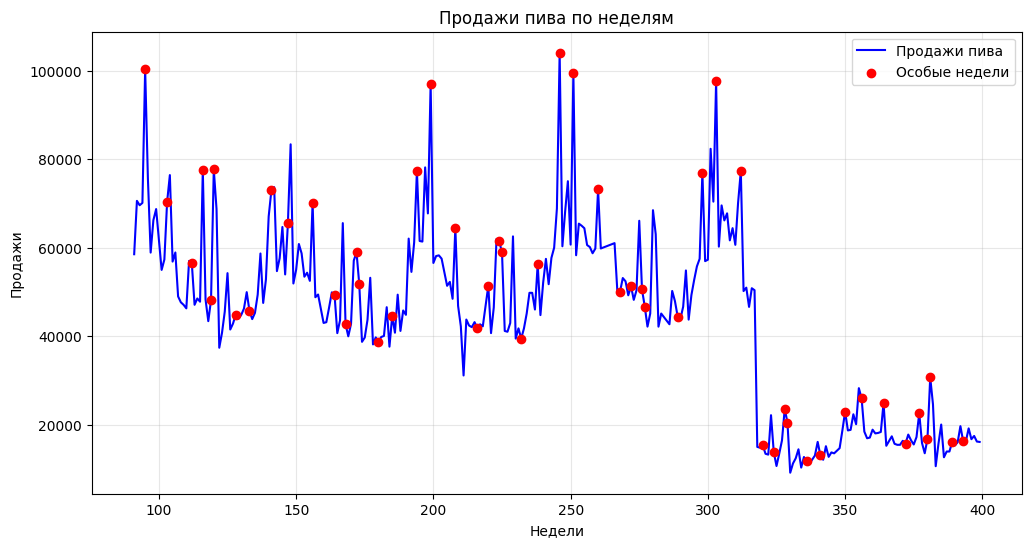

In [7]:
import matplotlib.pyplot as plt

# Группируем данные по неделям и суммируем продажи
weekly_sales_beer = beer_sales.groupby('week')['move'].sum()

# Находим уникальные особые недели
special_weeks_beer = beer_sales.loc[beer_sales['special_week'].notna(), 'week'].unique()

plt.figure(figsize=(12, 6))

# Линия продаж по неделям
plt.plot(weekly_sales_beer.index, weekly_sales_beer.values, label='Продажи пива', color='blue')

# Проверяем, есть ли особые недели в индексах weekly_sales
valid_special_weeks_beer = [week for week in special_weeks_beer if week in weekly_sales_beer.index]

# Выделяем особые недели красными точками
plt.scatter(
    valid_special_weeks_beer,
    weekly_sales_beer.loc[valid_special_weeks_beer],
    color='red',
    label='Особые недели',
    zorder=5
)

plt.xlabel('Недели')
plt.ylabel('Продажи')
plt.title('Продажи пива по неделям')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


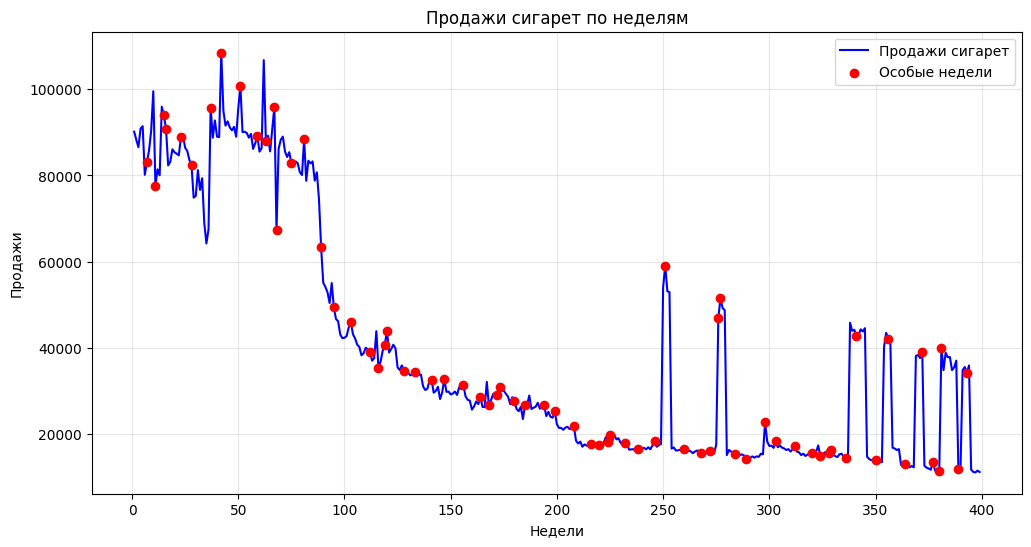

In [8]:
# Группируем данные по неделям и суммируем продажи
weekly_sales_cig = cig_sales.groupby('week')['move'].sum()

# Находим уникальные особые недели
special_weeks_cig = cig_sales.loc[cig_sales['special_week'].notna(), 'week'].unique()

plt.figure(figsize=(12, 6))

# Линия продаж по неделям
plt.plot(weekly_sales_cig.index, weekly_sales_cig.values, label='Продажи сигарет', color='blue')

# Проверяем, есть ли особые недели в индексах weekly_sales
valid_special_weeks_cig = [week for week in special_weeks_cig if week in weekly_sales_cig.index]

# Выделяем особые недели красными точками
plt.scatter(
    valid_special_weeks_cig,
    weekly_sales_cig.loc[valid_special_weeks_cig],
    color='red',
    label='Особые недели',
    zorder=5
)

plt.xlabel('Недели')
plt.ylabel('Продажи')
plt.title('Продажи сигарет по неделям')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


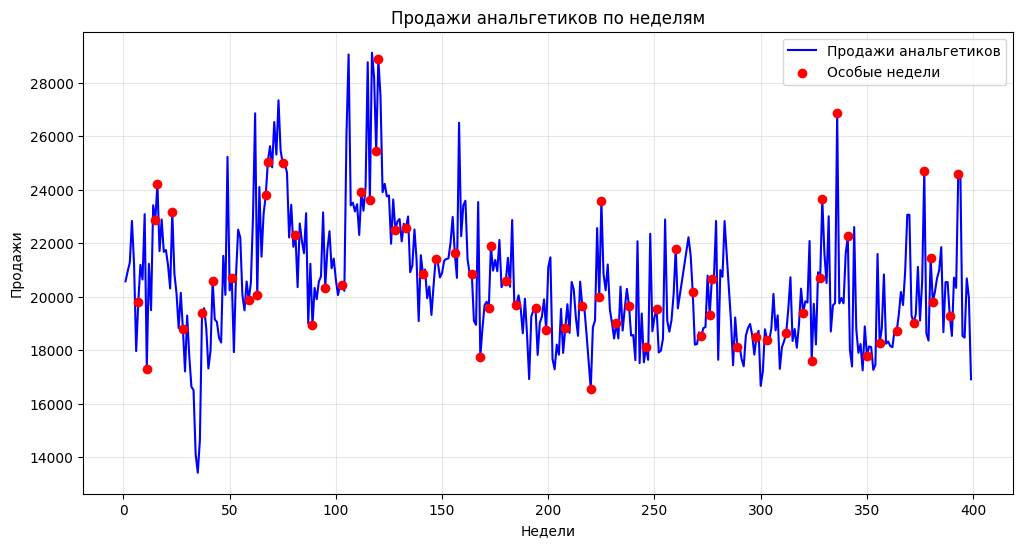

In [9]:
# Группируем данные по неделям и суммируем продажи
weekly_sales_ana = ana_sales.groupby('week')['move'].sum()

# Находим уникальные особые недели
special_weeks_ana = ana_sales.loc[ana_sales['special_week'].notna(), 'week'].unique()

plt.figure(figsize=(12, 6))

# Линия продаж по неделям
plt.plot(weekly_sales_ana.index, weekly_sales_ana.values, label='Продажи анальгетиков', color='blue')

# Проверяем, есть ли особые недели в индексах weekly_sales
valid_special_weeks_ana = [week for week in special_weeks_ana if week in weekly_sales_ana.index]

# Выделяем особые недели красными точками
plt.scatter(
    valid_special_weeks_ana,
    weekly_sales_ana.loc[valid_special_weeks_ana],
    color='red',
    label='Особые недели',
    zorder=5
)

plt.xlabel('Недели')
plt.ylabel('Продажи')
plt.title('Продажи анальгетиков по неделям')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Выводы анализа сезонности и трендов с использованием номеров недель
По графикам можно грубо предположить, что тренд потреблени пива, сигарет и анальгетиков убывает.
В сезоны важных событий, таких как: Новый год, Рождество, День независимости, Хеллоувин, наблюдается сильное увеличение покупок пива, сигарет и анальгетиков. Заметна цикличность в росте покупок пива каждые 50 недель: в этот временной отрезок происходит День независимости, что вызывает спрос на потребление алкоголя среди жителей америки. Такой цикличности у сигарет и анальгетиков не наблюдается.

В последние 150 недель наблюдаются скачки в потреблении никотина. Это возможно вызвано из-за **Бюджетный кризис и закрытие правительства:Вторая половина 1995 года была отмечена серьезным бюджетным кризисом между президентом Биллом Клинтоном (демократ) и республиканским Конгрессом, возглавляемым Ньютом Гингричем. С 13 по 19 ноября и снова с 16 декабря 1995 года по 6 января 1996 года произошло частичное закрытие правительства (шатдаун). Причиной стали разногласия по сокращению расходов на социальные программы и налоговую политику. Это событие привлекло огромное внимание СМИ и вызвало значительные неудобства для граждан.** и **Ураган "Офелия"
В октябре 1995 года восточное побережье США пострадало от урагана "Офелия", который вызвал разрушения и эвакуации.**

Наблюдается аномальный упадок покупок пива после начала 300 недели, ведь судя по событиям 2 половины 1995 года из-за стресса должен был вырасти спрос на алкоголь. Возможно просто меньше стали покупать пиво в этом конкретном магазине.

## Исследование корреляции между переменными


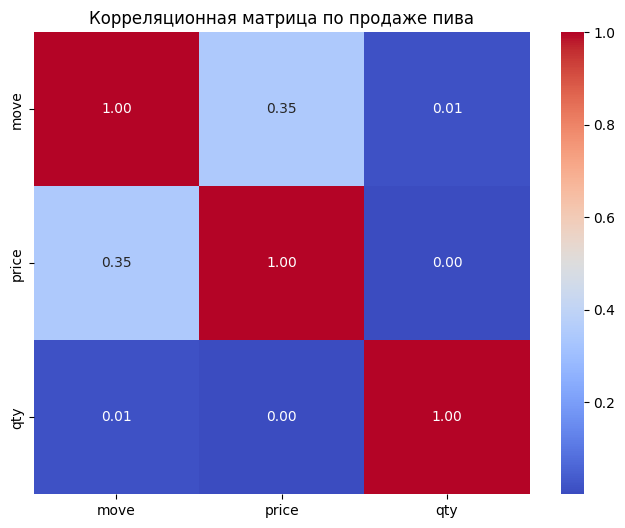

In [10]:
import seaborn as sns

# Корреляция между переменными в данных о продажах пива
corr = beer_sales[['move', 'price', 'qty']].corr()

# Тепловая карта корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица по продаже пива')
plt.show()


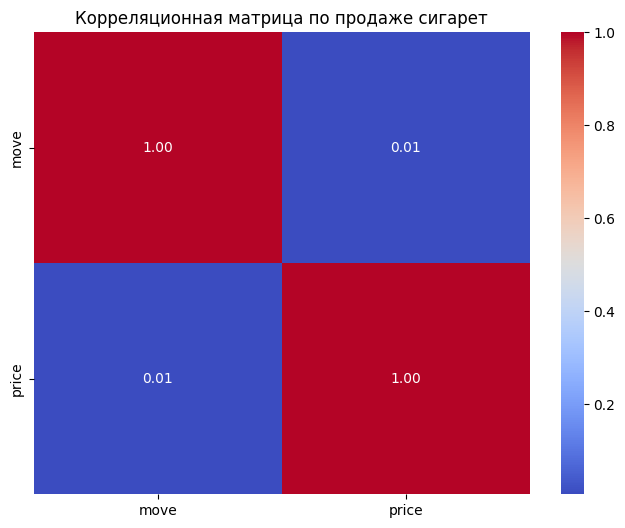

In [11]:
# Корреляция между переменными в данных о продажах сигарет
corr = cig_sales[['move', 'price']].corr()

# Тепловая карта корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица по продаже сигарет')
plt.show()

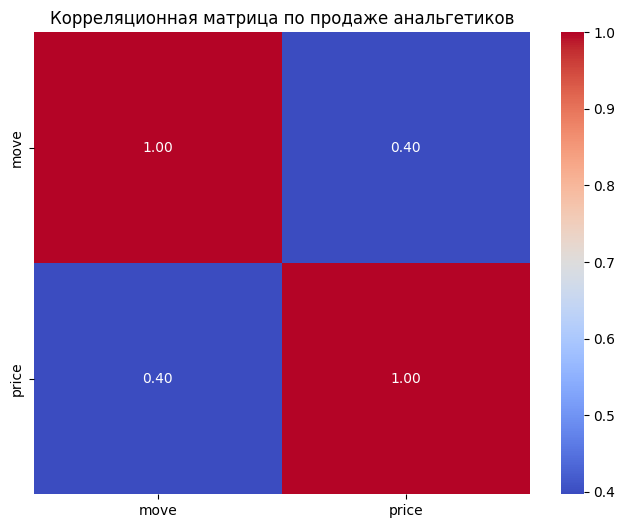

In [12]:
# Корреляция между переменными в данных о продажах анальгетиков
corr = ana_sales[['move', 'price']].corr()

# Тепловая карта корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица по продаже анальгетиков')
plt.show()

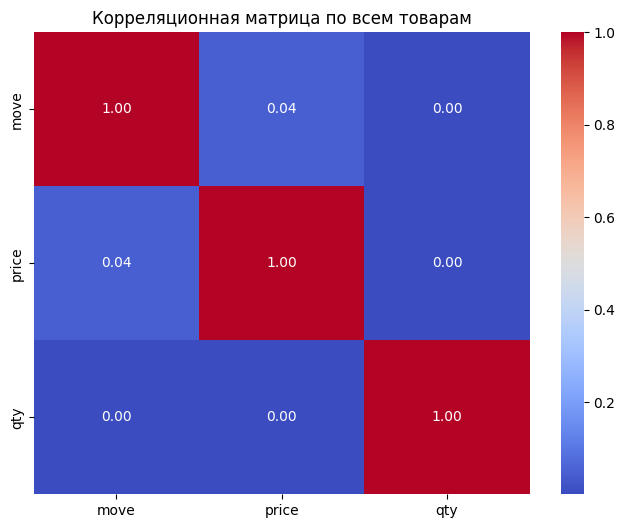

In [13]:
# Объединение датафреймов
all_sales = pd.concat([beer_sales, cig_sales, ana_sales], ignore_index=True)

# Корреляция между переменными в данных о продажах всех товаров
corr = all_sales[['move', 'price', 'qty']].corr()

# Тепловая карта корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица по всем товарам')
plt.show()

# Выводы исследования корреляции между переменными
Наблюдается слабая положительная зависимость количества проданных единиц от цены у пива и анальгетиков

## Анализ влияния сезонных событий на продажи

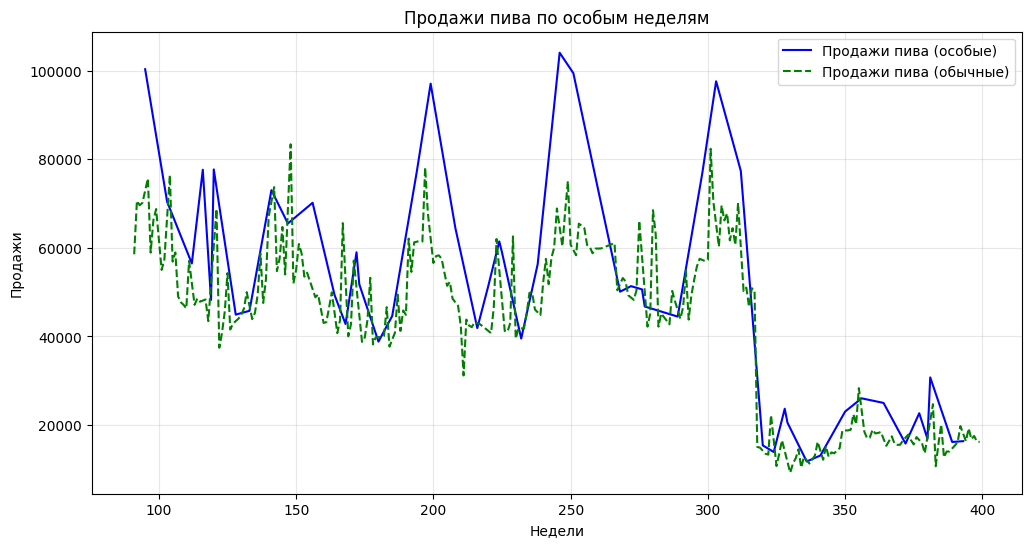

In [14]:
import matplotlib.pyplot as plt

# Группируем данные по особым неделям и суммируем продажи
weekly_sales_beer = beer_sales[beer_sales['special_week'].notna()].groupby('week')['move'].sum()
# Группируем данные по неделям и суммируем продажи для обычных недель
weekly_sales_beer_normal = beer_sales[beer_sales['special_week'].notna() == False].groupby('week')['move'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales_beer.index, weekly_sales_beer.values, label='Продажи пива (особые)', color='blue')
plt.plot(weekly_sales_beer_normal.index, weekly_sales_beer_normal.values, label='Продажи пива (обычные)', color='green', linestyle='--')

# Настройки графика
plt.xlabel('Недели')
plt.ylabel('Продажи')
plt.title('Продажи пива по особым неделям')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


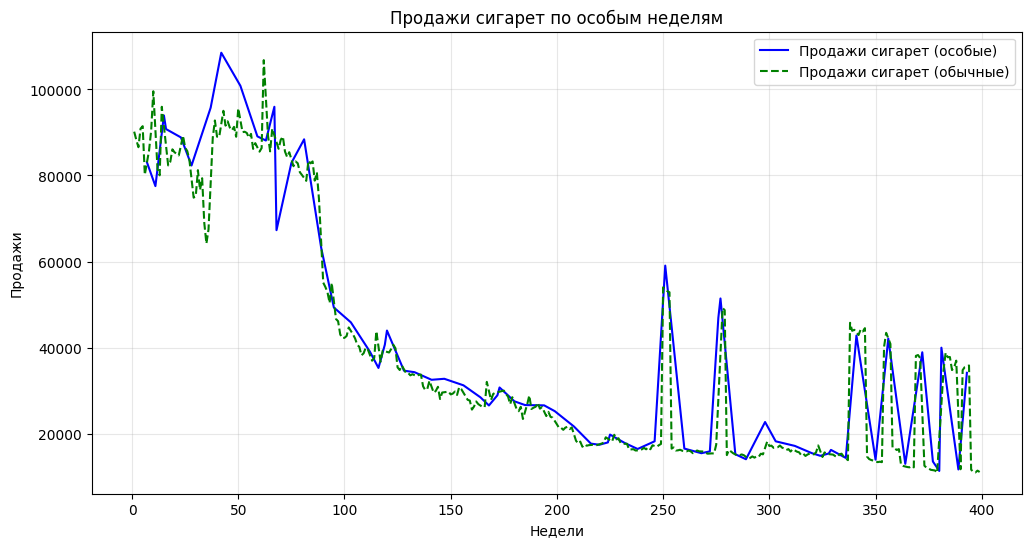

In [15]:
# Группируем данные по особым неделям и суммируем продажи
weekly_sales_cig = cig_sales[cig_sales['special_week'].notna()].groupby('week')['move'].sum()
# Группируем данные по неделям и суммируем продажи для обычных недель
weekly_sales_cig_normal = cig_sales[cig_sales['special_week'].notna() == False].groupby('week')['move'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales_cig.index, weekly_sales_cig.values, label='Продажи сигарет (особые)', color='blue')
plt.plot(weekly_sales_cig_normal.index, weekly_sales_cig_normal.values, label='Продажи сигарет (обычные)', color='green', linestyle='--')

# Настройки графика
plt.xlabel('Недели')
plt.ylabel('Продажи')
plt.title('Продажи сигарет по особым неделям')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


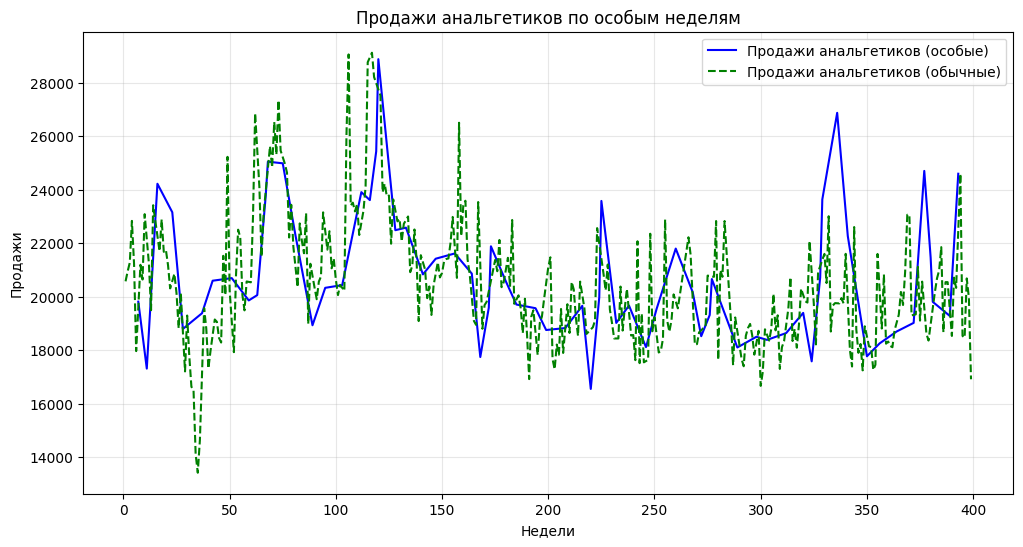

In [16]:
# Группируем данные по особым неделям и суммируем продажи
weekly_sales_ana = ana_sales[ana_sales['special_week'].notna()].groupby('week')['move'].sum()
# Группируем данные по неделям и суммируем продажи для обычных недель
weekly_sales_ana_normal = ana_sales[ana_sales['special_week'].notna() == False].groupby('week')['move'].sum()

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(weekly_sales_ana.index, weekly_sales_ana.values, label='Продажи анальгетиков (особые)', color='blue')
plt.plot(weekly_sales_ana_normal.index, weekly_sales_ana_normal.values, label='Продажи анальгетиков (обычные)', color='green', linestyle='--')

# Настройки графика
plt.xlabel('Недели')
plt.ylabel('Продажи')
plt.title('Продажи анальгетиков по особым неделям')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Выводы анализа влияния сезонных событий на продажи
Наблюдается, что в период особых недель количество покупок пива значительно больше, чем покупки в неособые недели. Спрос сигарет в особые дни незначительно больше, чем в обычные. Заметной разницы в покупке анальгетиков не наблюдается.


## Анализ демографических факторов

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Объединяем данные по продажам с демографическими данными по магазину
beer_sales_demographic = pd.merge(beer_sales, demographic_data, on='store', how='left')
cig_sales_demographic = pd.merge(cig_sales, demographic_data, on='store', how='left')
ana_sales_demographic = pd.merge(ana_sales, demographic_data, on='store', how='left')
all_sales_demographic = pd.merge(all_sales, demographic_data, on='store', how='left')


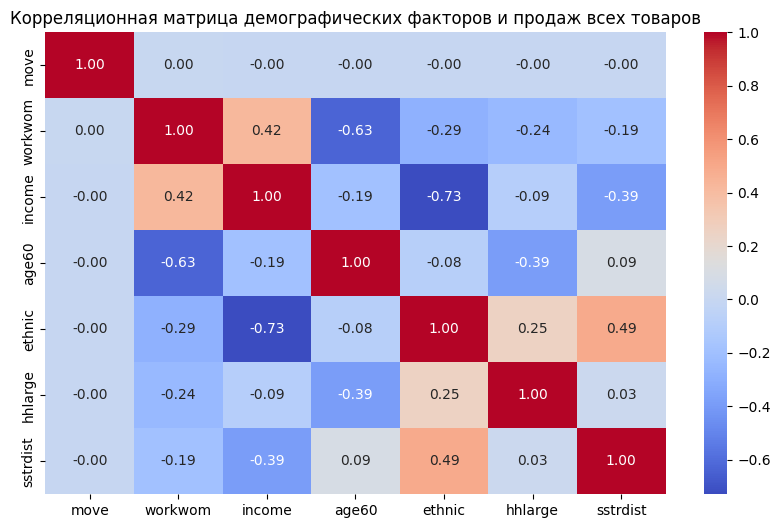

In [18]:
# Рассчитываем корреляцию между демографическими переменными и продажами 
correlation_data = all_sales_demographic[['move', 'workwom', 'income', 'age60', 'ethnic', 'hhlarge', 'sstrdist']]
correlation_matrix = correlation_data.corr()

# Визуализируем матрицу корреляций
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица демографических факторов и продаж всех товаров')
plt.show()


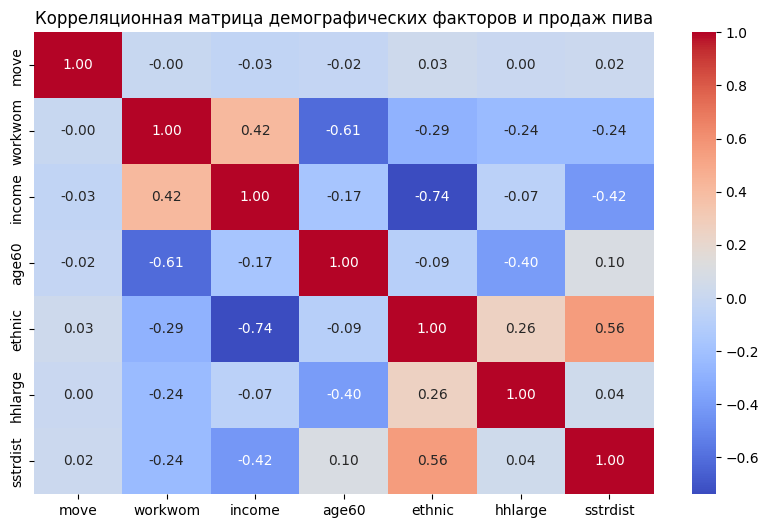

In [19]:
# Рассчитываем корреляцию между демографическими переменными и продажами пива
correlation_data = beer_sales_demographic[['move', 'workwom', 'income', 'age60', 'ethnic', 'hhlarge', 'sstrdist']]
correlation_matrix = correlation_data.corr()

# Визуализируем матрицу корреляций
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица демографических факторов и продаж пива')
plt.show()

# # Построение диаграмм рассеяния для каждого демографического признака
# demographic_columns = ['workwom', 'income', 'age60', 'ethnic', 'hhlarge', 'sstrdist']
# for column in demographic_columns:
#     plt.figure(figsize=(10, 6))
#     sns.scatterplot(x=column, y='move', data=beer_sales_demographic)
#     plt.title(f'Relationship Between {column} and Beer Sales')
#     plt.xlabel(column)
#     plt.ylabel('Beer Sales')
#     plt.show()


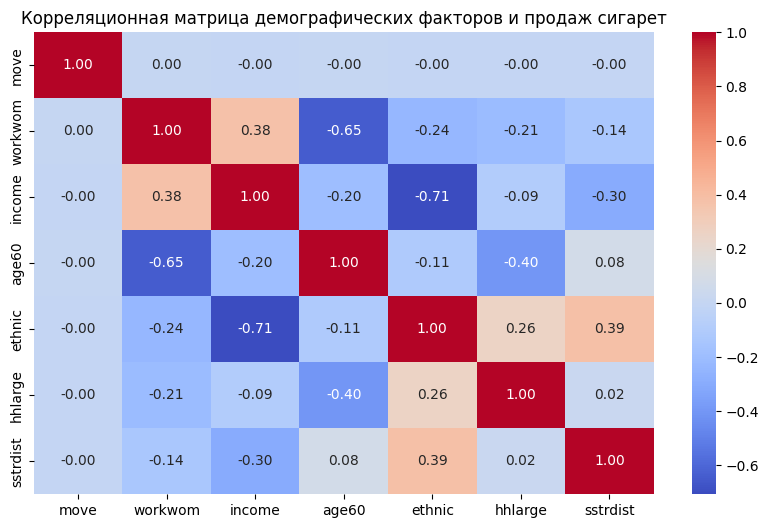

In [20]:
# Рассчитываем корреляцию между демографическими переменными и продажами сигарет
correlation_data = cig_sales_demographic[['move', 'workwom', 'income', 'age60', 'ethnic', 'hhlarge', 'sstrdist']]
correlation_matrix = correlation_data.corr()

# Визуализируем матрицу корреляций
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица демографических факторов и продаж сигарет')
plt.show()

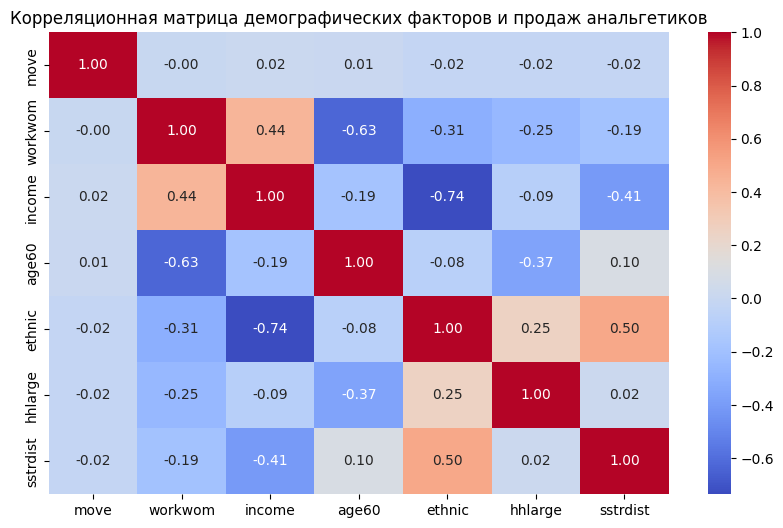

In [21]:
# Рассчитываем корреляцию между демографическими переменными и продажами сигарет
correlation_data = ana_sales_demographic[['move', 'workwom', 'income', 'age60', 'ethnic', 'hhlarge', 'sstrdist']]
correlation_matrix = correlation_data.corr()

# Визуализируем матрицу корреляций
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица демографических факторов и продаж анальгетиков')
plt.show()

In [22]:

print(demographic_data['age60'].describe())

print(demographic_data['age9'].describe())

print(demographic_data['educ'].describe())

print(demographic_data['ethnic'].describe())

print(demographic_data['workwom'].describe())

print(demographic_data['hval150'].describe())

print(demographic_data['income'].describe())

count    97.000000
mean      0.170046
std       0.063971
min       0.058054
25%       0.119626
50%       0.160414
75%       0.213309
max       0.312928
Name: age60, dtype: float64
count    97.000000
mean      0.140239
std       0.026921
min       0.046071
25%       0.120839
50%       0.139877
75%       0.155391
max       0.200156
Name: age9, dtype: float64
count    97.000000
mean      0.218815
std       0.107968
min       0.049550
25%       0.144310
50%       0.220789
75%       0.279952
max       0.528362
Name: educ, dtype: float64
count    97.000000
mean      0.153622
std       0.182897
min       0.022828
25%       0.043972
50%       0.074656
75%       0.187761
max       0.995691
Name: ethnic, dtype: float64
count    97.000000
mean      0.358464
std       0.051303
min       0.244463
25%       0.313190
50%       0.354977
75%       0.401900
max       0.472308
Name: workwom, dtype: float64
count    97.000000
mean      0.338482
std       0.236683
min       0.002509
25%       0.134418
50% 

# Выводы анализа демографических факторов
* Умеренная положительная связь: процента работающих женщин и заработка(логично), расстояния до ближайшего магазина в сети и процента чернокожих и латиноамериканцев(возможно они живут ближе к районам с магазинами).
* Слабая положительная связь: процента домохозяйств с 5 или более членами и процента чернокожих и латиноамериканцев(Стериотип или нестериотип)

* Сильная отрицательная связь: заработка и процента чернокожих и латиноамериканцев(без комментариев)
* Умеренная отрицательная связь: процента работающих женщин и процента людей старше 60
* Слабая отрицательная связь: процента работающих женщин - расстояния до ближайшего магазина в сети, процента работающих женщин - процента домохозяйств с 5, процента работающих женщин - процента чернокожих и латиноамериканцев; заработка - расстояния до ближайшего магазина в сети, заработка - процента людей старше 60

## Проверка трендов с использованием сглаживания (rolling mean)

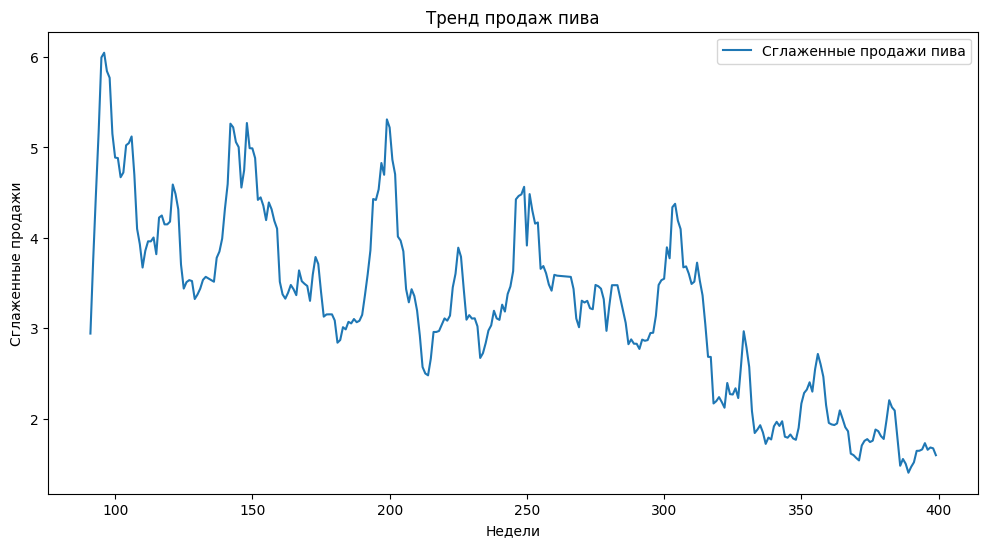

In [23]:
# Сглаживание данных для анализа тренда
beer_sales['rolling_sales'] = beer_sales.groupby('upc')['move'].rolling(window=4).mean().reset_index(level=0, drop=True)

# Построение тренда
plt.figure(figsize=(12,6))
plt.plot(beer_sales.groupby('week')['rolling_sales'].mean(), label='Сглаженные продажи пива')
plt.xlabel('Недели')
plt.ylabel('Сглаженные продажи')
plt.title('Тренд продаж пива')
plt.legend()
plt.show()


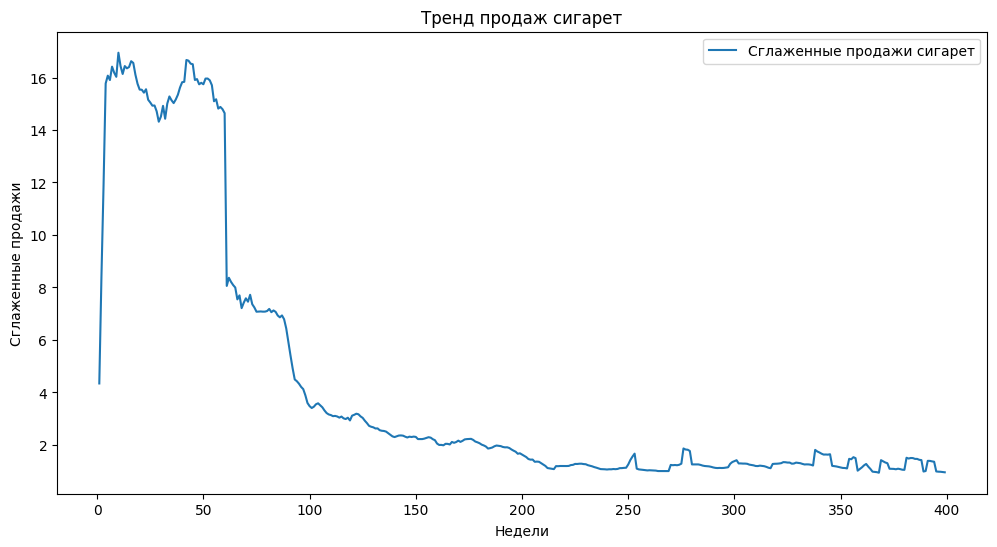

In [24]:
# Сглаживание данных для анализа тренда
cig_sales['rolling_sales'] = cig_sales.groupby('upc')['move'].rolling(window=4).mean().reset_index(level=0, drop=True)

# Построение тренда
plt.figure(figsize=(12,6))
plt.plot(cig_sales.groupby('week')['rolling_sales'].mean(), label='Сглаженные продажи сигарет')
plt.xlabel('Недели')
plt.ylabel('Сглаженные продажи')
plt.title('Тренд продаж сигарет')
plt.legend()
plt.show()


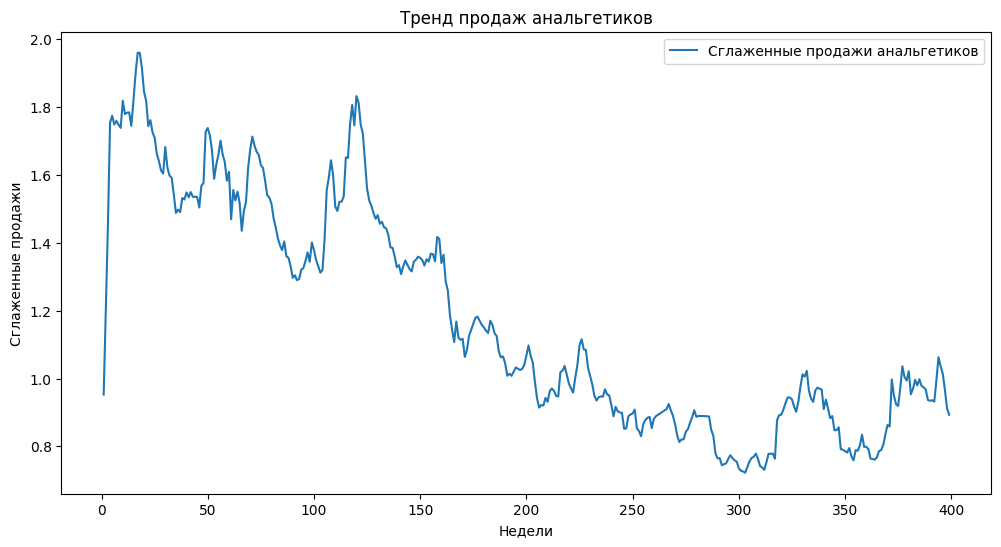

In [25]:
# Сглаживание данных для анализа тренда
ana_sales['rolling_sales'] = ana_sales.groupby('upc')['move'].rolling(window=4).mean().reset_index(level=0, drop=True)

# Построение тренда
plt.figure(figsize=(12,6))
plt.plot(ana_sales.groupby('week')['rolling_sales'].mean(), label='Сглаженные продажи анальгетиков')
plt.xlabel('Недели')
plt.ylabel('Сглаженные продажи')
plt.title('Тренд продаж анальгетиков')
plt.legend()
plt.show()


# Выводы анализа демографических факторов
Наблюдается снижение тренда потребления пива, сигарет, анальгетиков.

# Построить модель(и) прогноза спроса:
* Хорошо, если ты попробуешь несколько подходов (например, бустинг, AutoML) и сравнишь их.
* Желательно, чтобы выбор моделей был обоснован.


* **Градиентный бустинг**: Это один из самых мощных и популярных методов для прогнозирования на основе табличных данных. Например, модель **XGBoost** или **LightGBM**. Эти модели могут эффективно работать с числовыми и категориальными признаками, хорошо обрабатывают взаимодействие признаков и часто показывают высокую точность.
* **AutoML**: Платформы AutoML, такие как TPOT или H2O.ai, могут автоматически подбирать модели и параметры для вашего набора данных.
* **Случайный Лес** — это ансамблевый метод, который строит несколько решающих деревьев и усредняет их прогнозы для уменьшения дисперсии и повышения точности. Это один из самых простых и популярных методов, который также показывает хорошую производительность на различных типах задач.

In [26]:
#!pip install xgboost
#!pip install lightgbm
#!pip install tpot

# Модели спроса всех товаров(объедилил пиво, сигареты и анальгетики)

In [27]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import lightgbm as lgb
import tpot
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV




# Формируем признаки и целевую переменную
X = all_sales_demographic[['price', 'age60', 'age9', 'educ', 'ethnic', 'income', 'hhlarge', 'workwom', 'hval150', 'sstrdist', 'sstrvol', 'cpdist5', 'cpwvol5']]
y = all_sales_demographic['move']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [28]:

"""Модель 1: XGBoost"""

# Список гиперпараметров для поиска лучшие гиперпараметров
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Оптимальное решение, но долгое
# # GridSearch для XGBoost
# xgb_model = XGBRegressor()
# xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
# xgb_grid.fit(X_train, y_train)

# # Лучшие параметры и оценка
# print("Лучшие параметры для XGBoost:", xgb_grid.best_params_)
# xgb_best_model = xgb_grid.best_estimator_

xgb_random = RandomizedSearchCV(
    XGBRegressor(), 
    param_distributions=xgb_params, 
    n_iter=1,  # Проверить только 1 случайных комбинаций
    cv=3, 
    scoring='neg_mean_squared_error', 
    random_state=17, 
    n_jobs=-1
)
xgb_random.fit(X_train, y_train)

# Прогнозы и оценка RMSE
y_pred_xgb = xgb_random.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"RMSE для XGBoost: {xgb_rmse}")


RMSE для XGBoost: 23.88876827355774


In [29]:
"""Модель 1: XGBoost"""
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f'RMSE для XGBoost: {xgb_rmse}')


RMSE для XGBoost: 21.955362761282586


### Т.к. "задание не направлено на создание идеальной модели или решение сложных бизнес-проблем." Не нужно добиваться идеальной модели

In [30]:
"""Модель 2: RandomForest"""

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Модель Случайный Лес с оптимизированными параметрами
rf_model = RandomForestRegressor(
    n_estimators=20,           # Меньше деревьев
    max_depth=5,                # Ограничение глубины
    n_jobs=-1,                  # Использование всех ядер процессора
    min_samples_split=10,       # Минимальное количество объектов для разбиения
    min_samples_leaf=5         # Минимальное количество объектов в листе
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f'RMSE для случайного леса: {rf_rmse}')


RMSE для случайного леса: 23.978514317172937


## Для примера: модель для пива

In [31]:

# Формируем признаки и целевую переменную
X = beer_sales_demographic[['price', 'age60', 'age9', 'educ', 'ethnic', 'income', 'hhlarge', 'workwom', 'hval150', 'sstrdist', 'sstrvol', 'cpdist5', 'cpwvol5']]
y = beer_sales_demographic['move']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [32]:
"""Модель 1: XGBoost"""
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f'RMSE для XGBoost: {xgb_rmse}')


RMSE для XGBoost: 7.811655897714771


In [33]:
"""Модель 2: RandomForest"""

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Модель Случайный Лес с оптимизированными параметрами
rf_model = RandomForestRegressor(
    n_estimators=20,           # Меньше деревьев
    max_depth=5,                # Ограничение глубины
    n_jobs=-1,                  # Использование всех ядер процессора
    min_samples_split=10,       # Минимальное количество объектов для разбиения
    min_samples_leaf=5         # Минимальное количество объектов в листе
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f'RMSE для случайного леса: {rf_rmse}')


RMSE для случайного леса: 7.942127022737803


# Итог
* XGBoost - Высокая точность, регуляризация, обработка пропусков; Хорошо подходит, когда точность дл нас критична(спрос покупки товаров для бизнеса)
* Случайный Лес - Простота, хорошо работает с различными типами данных; Хорошо защищен от выбросов и шума данных
* AutoML (Не реализовал, т.к. метод требует долгого времени работы) - Автоматический подбор моделей и гиперпараметров; Лучше всего подходит дл облачных сервисов с огромным количеством данных

Значением среднеквадратического отклонения(RMSE) доволен. 


# (Необязательно, но интересно ;-)) Анализ эластичности.

In [35]:
import xgboost as xgb 

# Получаем предсказания модели для тестовой выборки
y_pred_xgb = xgb_model.predict(X_test)


price_idx = X.columns.get_loc('price')  # Индекс для 'price'

# Применим модель XGBRegressor для получения градиентов (производных) по признаку
dtest = xgb.DMatrix(X_test)  # Преобразуем X_test в DMatrix
gradients = xgb_model.get_booster().predict(dtest, pred_contribs=True)

# Получим производные для 'price'
grad_price = gradients[:, price_idx]

# Эластичность = (дельта в целевой переменной) / (дельта в цене) * (цена / целевая переменная)
elasticity = grad_price * (X_test['price'] / y_pred_xgb)

# Выведем среднюю эластичность
mean_elasticity = np.mean(elasticity)
print(f"Средняя эластичность модели XGB по пиву: {mean_elasticity}")


Средняя эластичность модели XGB по пиву: 1.1663430801246037


## E=1.166 означает, что:
При увеличении цены на 1% спрос на пиво уменьшится на 1.166% (в среднем).
Аналогично, при снижении цены на 1% спрос увеличится на 1.166%.
Так как значение эластичности больше 1, спрос на пиво считается эластичным, что значит, что покупатели очень чувствительны к изменениям цены.

In [44]:
xgb_random_model=xgb_random.best_estimator_

# Получаем предсказания модели для тестовой выборки
y_pred_xgb = xgb_random_model.predict(X_test)

# Рассчитаем производную по логарифму цены для оценки эластичности
log_price_idx = X.columns.get_loc('price')  # Индекс для 'log_price'

# Применим модель XGBRegressor для получения градиентов (производных) по признаку
dtest = xgb.DMatrix(X_test)  # Преобразуем X_test в DMatrix
gradients = xgb_random_model.get_booster().predict(dtest, pred_contribs=True)

# Получим производные для 'price'
grad_price = gradients[:, price_idx]

# Эластичность = (дельта в целевой переменной) / (дельта в цене) * (цена / целевая переменная)
elasticity = grad_price * (X_test['price'] / y_pred_xgb)

# Выведем среднюю эластичность
mean_elasticity = np.mean(elasticity)
print(f"Средняя эластичность модели XGB по всем товарам: {mean_elasticity}")


Средняя эластичность модели XGB по всем товарам: 1.3436533772609496


## E=1.344 означает, что:
При увеличении цены на 1% спрос на пиво уменьшится на 1.344% (в среднем).
Аналогично, при снижении цены на 1% спрос увеличится на 1.344%.
Так как значение эластичности больше 1, спрос на пиво считается эластичным, что значит, что покупатели очень чувствительны к изменениям цены.